# Prediction Visualiser

Given a model checkpoint and a video ID, this notebook:
1. Loads features (video, audio, text) for the requested video
2. Runs the model and captures per-FPN-level action scores
3. Draws a three-panel timeline matching Fig. 3 of the paper:
   - **Top**: per-frame action scores aggregated across all pyramid levels
   - **Middle**: weighted onset / offset histograms from the regression output
   - **Bottom**: ground-truth and predicted temporal segments on a shared timeline

## 1 — Configuration

Set the three paths below and run all cells.

In [22]:
import os

CONFIG_PATH     = 'configs/experiments/trifuse_tridet.yaml'
CHECKPOINT_PATH = 'runs/exp/trifuse_tridet/model_best.pth.tar'
VIDEO_ID        = 'bit_f174RJMAVSdF'
#VIDEO_ID        = 'bit_KzHMHwPZPNIp'
#VIDEO_ID        = 'bit_1kW6COenXnwa'
#VIDEO_ID        = 'bit_uTkBtKfWkLDk'
SUBSET          = 'val'                 # 'train' | 'val' | 'test'
VIDEO_DIR       = '../data/hateclipseg/dataset/videos'

DISPLAY_THRESHOLD = 0.00
MAX_SHOW = 15
N_FRAMES = 8
N_TRANSCRIPT_SEGS = 8

SHOW_FRAMES      = True   # row of equally-spaced video frames
SHOW_TRANSCRIPT  = False   # row of transcript segments (requires openai-whisper)
SHOW_WAVEFORM    = False   # audio waveform
SHOW_SCORES      = True  # per-frame action scores bar chart
SHOW_ONSETS      = True  # onset / offset histogram

## 2 — Imports & path setup

In [23]:
import sys, yaml, json
import numpy as np
import torch
import cv2
import librosa
import textwrap
import whisper
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec

_notebook_dir = os.path.dirname(os.path.abspath('.'))
_src_dir = os.path.join(os.path.dirname(os.path.abspath('')), 'adapted_actionformer')
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)

from libs.modeling.meta_arch import HatefulContentLocalizer

%matplotlib inline
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 3 — Load config, model, annotations

In [24]:
def load_config(path: str) -> dict:
    """Load YAML and resolve relative feature/annotation paths."""
    config_dir = os.path.dirname(os.path.abspath(path))
    with open(path) as f:
        cfg = yaml.safe_load(f)
    ds = cfg['dataset']
    for key in ('video_feat_dir', 'audio_feat_dir', 'text_feat_dir', 'annotation_file'):
        if key in ds and not os.path.isabs(ds[key]):
            ds[key] = os.path.normpath(os.path.join(config_dir, ds[key]))
    return cfg


cfg = load_config(CONFIG_PATH)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Annotation file: {cfg["dataset"]["annotation_file"]}')

# Load model
model = HatefulContentLocalizer(cfg).to(device)
ckpt  = torch.load(CHECKPOINT_PATH, map_location='cpu')
model.load_state_dict(ckpt.get('state_dict', ckpt))
model.eval()
print(f'Loaded checkpoint: {CHECKPOINT_PATH}')

# Load annotations
with open(cfg['dataset']['annotation_file']) as f:
    annotations = json.load(f)['database']
print(f'Annotation DB size: {len(annotations)} videos')

Device: cuda
Annotation file: c:\Users\Georgiy\Documents\coursework\hateful content localisation\data\hateclipseg\dataset\hateclipseg.json
Loaded checkpoint: runs/exp/trifuse_tridet/model_best.pth.tar
Annotation DB size: 431 videos


## 4 — Load features for a single video

In [25]:
def load_video_features(cfg: dict, video_id: str) -> dict:
    """
    Load and pad/crop the three modality feature files for `video_id`.
    Returns a batch dict ready for the model (batch size = 1).
    """
    ds   = cfg['dataset']
    msl  = ds.get('max_seq_len', 512)

    def _load(feat_dir: str) -> torch.Tensor:
        path = os.path.join(feat_dir, f'{video_id}.pt')
        t    = torch.load(path, map_location='cpu').float()
        if t.ndim == 1:
            t = t.unsqueeze(0)
        return t  # (T, D)

    video_feat = _load(ds['video_feat_dir'])  # (T, 768)
    audio_feat = _load(ds['audio_feat_dir'])  # (T, 1024)
    text_feat  = _load(ds['text_feat_dir'])   # (T, 768)

    T = video_feat.shape[0]

    # Align audio / text length to video
    def _align(feat: torch.Tensor, target_len: int) -> torch.Tensor:
        L = feat.shape[0]
        if L < target_len:
            pad = torch.zeros(target_len - L, feat.shape[1])
            feat = torch.cat([feat, pad], dim=0)
        return feat[:target_len]

    audio_feat = _align(audio_feat, T)
    text_feat  = _align(text_feat,  T)

    # Pad / truncate to max_seq_len
    valid_T = min(T, msl)
    mask    = torch.zeros(msl)
    mask[:valid_T] = 1.0

    def _pad_to(feat: torch.Tensor) -> torch.Tensor:
        t2 = torch.zeros(msl, feat.shape[1])
        t2[:valid_T] = feat[:valid_T]
        return t2

    batch = {
        'video_id'   : [video_id],
        'video_feat' : _pad_to(video_feat).unsqueeze(0),  # (1, T_max, 768)
        'audio_feat' : _pad_to(audio_feat).unsqueeze(0),  # (1, T_max, 1024)
        'text_feat'  : _pad_to(text_feat).unsqueeze(0),   # (1, T_max, 768)
        'mask'       : mask.unsqueeze(0),                  # (1, T_max)
        'duration'   : [annotations[video_id]['duration'] if video_id in annotations else float(T)],
    }
    return batch, valid_T


batch, valid_T = load_video_features(cfg, VIDEO_ID)
duration = batch['duration'][0]
print(f'Video ID : {VIDEO_ID}')
print(f'Duration : {duration:.1f} s  |  Feature frames: {valid_T}')
if VIDEO_ID in annotations:
    ann = annotations[VIDEO_ID]
    print(f'Subset   : {ann["subset"]}')
    for seg in ann.get('annotations', []):
        print(f'  GT segment: {seg["segment"][0]:.1f}s – {seg["segment"][1]:.1f}s  label={seg["label"]}')
else:
    print('(video not found in annotation file — no ground truth available)')

Video ID : bit_f174RJMAVSdF
Duration : 254.0 s  |  Feature frames: 254
Subset   : val
  GT segment: 0.0s – 7.7s  label=hate
  GT segment: 13.8s – 20.7s  label=hate
  GT segment: 20.7s – 29.6s  label=hate
  GT segment: 29.6s – 38.4s  label=hate
  GT segment: 38.4s – 42.5s  label=hate
  GT segment: 42.5s – 52.3s  label=hate
  GT segment: 52.3s – 61.5s  label=hate
  GT segment: 61.5s – 69.9s  label=hate
  GT segment: 69.9s – 72.1s  label=hate
  GT segment: 72.1s – 80.9s  label=hate
  GT segment: 80.9s – 87.9s  label=hate
  GT segment: 87.9s – 97.2s  label=hate
  GT segment: 97.2s – 107.1s  label=hate
  GT segment: 107.1s – 116.6s  label=hate
  GT segment: 132.5s – 140.4s  label=hate
  GT segment: 162.2s – 169.7s  label=hate
  GT segment: 169.7s – 176.4s  label=hate
  GT segment: 176.4s – 185.2s  label=hate
  GT segment: 185.2s – 195.2s  label=hate
  GT segment: 195.2s – 199.7s  label=hate
  GT segment: 199.7s – 209.7s  label=hate
  GT segment: 209.7s – 219.7s  label=hate
  GT segment: 219

## 5 — Run inference and capture per-level scores

In [26]:
@torch.no_grad()
def run_inference_with_internals(model, batch, device):
    """
    Mirrors HatefulContentLocalizer.forward() in eval mode but also returns
    the raw per-FPN-level cls scores and point positions for visualisation.

    Compatible with both the standard ActionFormer head (RegHead) and the
    TriDet Trident-head (TridentRegHead + start_head + end_head).

    Returns
    -------
    results      : list of dicts (same format as model.inference output)
    level_scores : list[np.ndarray]  — per-level sigmoid scores (T_i,)
    level_times  : list[np.ndarray]  — per-level point centres in seconds (T_i,)
    level_offsets: list[np.ndarray]  — per-level decoded (start, end) in seconds (T_i, 2)
    """
    from libs.utils.nms import soft_nms
    from torch.nn import functional as F

    text  = batch['text_feat'].to(device)
    audio = batch['audio_feat'].to(device)
    video = batch['video_feat'].to(device)
    mask  = batch['mask'].to(device)

    # Stage 1: preprocessor
    fused = model.preprocessor(text, audio, video)       # (1, T, fused_dim)
    x     = fused.permute(0, 2, 1)                        # (1, fused_dim, T)
    mask_bcT = mask.unsqueeze(1).bool()                   # (1, 1, T)

    # Stage 2: backbone + neck
    feats, masks         = model.backbone(x, mask_bcT)
    fpn_feats, fpn_masks = model.neck(feats, masks)

    # Grid points: list[(T_i, 4)]  columns: (t_centre, reg_min, reg_max, stride)
    points = model.point_generator(fpn_feats)

    # Stage 3: heads
    raw_cls  = model.cls_head(fpn_feats, fpn_masks)   # list[(1, C, T_i)]
    raw_off  = model.reg_head(fpn_feats, fpn_masks)   # list[(1, 2 or 2*(nb+1), T_i)]
    out_cls  = [c.permute(0, 2, 1) for c in raw_cls]  # list[(1, T_i, C)]
    out_off  = [o.permute(0, 2, 1) for o in raw_off]  # list[(1, T_i, 2 or 2*(nb+1))]
    masks_2d = [m.squeeze(1) for m in fpn_masks]       # list[(1, T_i)]

    # Trident-head boundary logits (only present when head type == 'trident')
    if model.use_trident_head:
        raw_lb = model.start_head(fpn_feats, fpn_masks)  # list[(1, C, T_i)]
        raw_rb = model.end_head(fpn_feats, fpn_masks)    # list[(1, C, T_i)]
    else:
        raw_lb = raw_rb = None

    fps = cfg['dataset'].get('feature_fps', 1.0)

    # Collect per-level scores and decoded segments
    level_scores  = []
    level_times   = []
    level_offsets = []

    segs_all, scores_all = [], []

    for lvl, (cls_i, off_i, pts_i, msk_i) in enumerate(
        zip(out_cls, out_off, points, masks_2d)
    ):
        # scores: (T_i,) — masked
        score = (cls_i[0].sigmoid() * msk_i[0].unsqueeze(-1)).squeeze(-1).cpu()

        pts_cpu = pts_i.cpu()  # (T_i, 4)
        t_centres = pts_cpu[:, 0].numpy() / fps  # in seconds

        # ── Offset decoding: standard vs Trident-head ────────────────────────
        if model.use_trident_head:
            nb = model.num_bins
            sb = raw_lb[lvl][0]  # (C, T_i) — start boundary logits
            eb = raw_rb[lvl][0]  # (C, T_i) — end   boundary logits

            # Build sliding-window boundary neighbour views (C, T_i, nb+1)
            x_pad    = F.pad(sb, (nb, 0), mode='constant', value=0).unsqueeze(-1)
            sz       = list(x_pad.size()); sz[-1] = nb + 1; sz[-2] -= nb
            st       = list(x_pad.stride()); st[-2] = st[-1]
            start_nb = x_pad.as_strided(size=sz, stride=st)

            x_pad   = F.pad(eb, (0, nb), mode='constant', value=0).unsqueeze(-1)
            end_nb  = x_pad.as_strided(size=sz, stride=st)

            # decode_offset returns (C, T_i, 2); select class 0 for binary
            off_decoded = model.decode_offset(off_i[0], start_nb, end_nb)
            off_cpu     = off_decoded[0].cpu()  # (T_i, 2)
        else:
            off_cpu = off_i[0].cpu()  # (T_i, 2)

        seg_l   = (pts_cpu[:, 0] - off_cpu[:, 0] * pts_cpu[:, 3]).numpy() / fps
        seg_r   = (pts_cpu[:, 0] + off_cpu[:, 1] * pts_cpu[:, 3]).numpy() / fps
        decoded = np.stack([seg_l, seg_r], axis=1)  # (T_i, 2)

        score_np = score.numpy()
        level_scores.append(score_np)
        level_times.append(t_centres)
        level_offsets.append(decoded)

        # Collect all detections above threshold for NMS
        keep = score > model.score_threshold
        if keep.sum() > 0:
            segs_k = torch.tensor(decoded[keep.numpy()])
            segs_all.append(segs_k * fps)  # NMS expects feature-frame units
            scores_all.append(score[keep])

    # Apply Soft-NMS
    if segs_all:
        segs_cat   = torch.cat(segs_all, dim=0)
        scores_cat = torch.cat(scores_all, dim=0)
        segs_nms, scores_nms = soft_nms(
            segs_cat, scores_cat,
            sigma=model.nms_sigma,
            min_score=model.score_threshold,
            max_num=model.max_detections,
        )
        segs_sec = (segs_nms / fps).clamp(min=0.0, max=float(batch['duration'][0]))
    else:
        segs_sec   = torch.zeros((0, 2))
        scores_nms = torch.zeros((0,))

    results = [{
        'video_id': batch['video_id'][0],
        'segments': segs_sec,
        'scores'  : scores_nms,
        'labels'  : torch.zeros(segs_sec.shape[0], dtype=torch.long),
    }]

    return results, level_scores, level_times, level_offsets


results, level_scores, level_times, level_offsets = run_inference_with_internals(
    model, batch, device
)
res = results[0]
print(f'Predicted segments after NMS: {res["segments"].shape[0]}')
for i, (s, e, sc) in enumerate(zip(
    res['segments'][:, 0], res['segments'][:, 1], res['scores']
)):
    print(f'  [{i}]  {s:.2f}s – {e:.2f}s   score={sc:.4f}')

Predicted segments after NMS: 200
  [0]  175.98s – 186.02s   score=0.6599
  [1]  52.59s – 63.42s   score=0.6271
  [2]  41.93s – 53.63s   score=0.5949
  [3]  86.80s – 97.36s   score=0.5781
  [4]  71.19s – 81.96s   score=0.5576
  [5]  19.49s – 31.36s   score=0.5548
  [6]  185.54s – 194.68s   score=0.5395
  [7]  38.22s – 42.76s   score=0.5300
  [8]  139.95s – 145.70s   score=0.4945
  [9]  28.94s – 38.54s   score=0.4889
  [10]  95.51s – 107.91s   score=0.4761
  [11]  0.00s – 8.53s   score=0.4708
  [12]  169.88s – 176.95s   score=0.4657
  [13]  61.47s – 71.40s   score=0.4602
  [14]  105.02s – 118.01s   score=0.4523
  [15]  145.78s – 155.31s   score=0.4495
  [16]  245.66s – 254.00s   score=0.4423
  [17]  161.60s – 170.02s   score=0.4211
  [18]  6.18s – 13.86s   score=0.3782
  [19]  79.46s – 88.25s   score=0.3778
  [20]  193.96s – 205.87s   score=0.3716
  [21]  153.13s – 163.55s   score=0.3336
  [22]  219.48s – 233.40s   score=0.3175
  [23]  235.76s – 248.25s   score=0.2755
  [24]  68.89s – 7

## 6 — Visualise

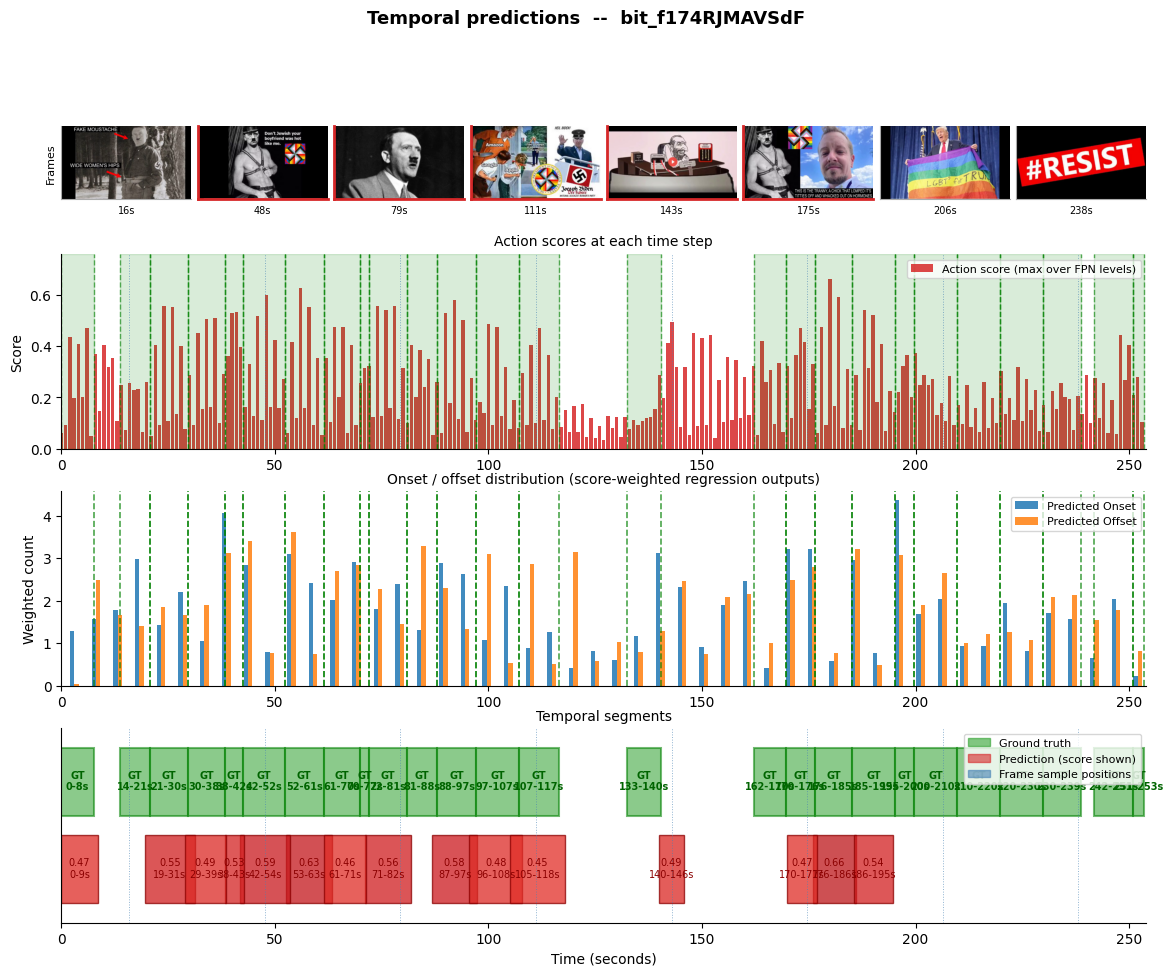

In [27]:
def extract_frames(video_id: str, video_dir: str, n_frames: int, duration: float):
    """
    Extract `n_frames` equally-spaced frames from the video file.

    Returns
    -------
    frames     : list of np.ndarray (H, W, 3) in RGB order
    timestamps : list of float -- timestamp in seconds for each frame
    """
    video_path = os.path.join(video_dir, f'{video_id}.mp4')
    if not os.path.exists(video_path):
        return [], []

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps_vid      = cap.get(cv2.CAP_PROP_FPS) or 25.0

    timestamps = np.linspace(0, duration, n_frames, endpoint=False) + duration / (2 * n_frames)
    timestamps = np.clip(timestamps, 0, duration)

    frames = []
    for t in timestamps:
        frame_idx = int(t * fps_vid)
        frame_idx = min(frame_idx, total_frames - 1)
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        if ok:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        else:
            frames.append(np.zeros((64, 64, 3), dtype=np.uint8))

    cap.release()
    return frames, timestamps.tolist()


def load_waveform(video_id: str, video_dir: str, duration: float, target_sr: int = 200):
    """
    Load audio from the video file and return a downsampled waveform suitable
    for plotting.

    Returns
    -------
    t_wave : np.ndarray  -- time axis in seconds
    wave   : np.ndarray  -- amplitude samples (mono)
    """
    video_path = os.path.join(video_dir, f'{video_id}.mp4')
    if not os.path.exists(video_path):
        return None, None

    y, sr = librosa.load(video_path, sr=target_sr, mono=True, duration=duration)
    t_wave = np.linspace(0, len(y) / sr, len(y))
    return t_wave, y


def load_transcript(video_id: str, video_dir: str, n_segs: int):
    """
    Transcribe the video with Whisper (base model) and return up to n_segs
    evenly-sampled segments, each a dict with keys 'start', 'end', 'text'.
    """
    video_path = os.path.join(video_dir, f'{video_id}.mp4')
    if not os.path.exists(video_path):
        return []
    try:
        model = whisper.load_model('base')
        result = model.transcribe(video_path, word_timestamps=False)
        segments = result.get('segments', [])
        if not segments:
            return []
        if len(segments) <= n_segs:
            return list(segments)
        indices = np.linspace(0, len(segments) - 1, n_segs, dtype=int)
        return [segments[i] for i in indices]
    except Exception as exc:
        print(f'[transcript] Whisper failed: {exc}')
        return []


def make_dense_score_curve(level_scores, level_times, duration, fps=1.0):
    n_bins = int(np.ceil(duration)) + 1
    dense  = np.zeros(n_bins)
    for scores, times in zip(level_scores, level_times):
        for t, s in zip(times, scores):
            idx = int(round(t))
            if 0 <= idx < n_bins:
                dense[idx] = max(dense[idx], float(s))
    return np.arange(n_bins), dense


def make_boundary_histograms(level_scores, level_offsets, level_times, duration, n_bins=50):
    bin_edges = np.linspace(0, duration, n_bins + 1)
    onset_hist  = np.zeros(n_bins)
    offset_hist = np.zeros(n_bins)

    for scores, offsets, times in zip(level_scores, level_offsets, level_times):
        for i, (s, (t_start, t_end)) in enumerate(zip(scores, offsets)):
            if s < 1e-4:
                continue
            idx_s = np.searchsorted(bin_edges, t_start, side='right') - 1
            idx_e = np.searchsorted(bin_edges, t_end,   side='right') - 1
            if 0 <= idx_s < n_bins:
                onset_hist[idx_s]  += float(s)
            if 0 <= idx_e < n_bins:
                offset_hist[idx_e] += float(s)

    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return bin_centres, onset_hist, offset_hist


def visualise(video_id, res, level_scores, level_times, level_offsets,
              annotations, duration, display_threshold=0.10, max_show=10,
              video_dir=None, n_frames=8, n_transcript_segs=8,
              show_frames=True, show_transcript=True, show_waveform=True,
              show_scores=True, show_onsets=True):

    fps = cfg['dataset'].get('feature_fps', 1.0)

    if show_scores:
        t_axis, dense = make_dense_score_curve(level_scores, level_times, duration, fps)
    if show_onsets:
        bin_c, onset_h, offset_h = make_boundary_histograms(
            level_scores, level_offsets, level_times, duration
        )

    # Ground truth
    gt_segs = []
    if video_id in annotations:
        for ann in annotations[video_id].get('annotations', []):
            gt_segs.append(ann['segment'])

    # Predicted segments above display threshold, sorted by score
    pred_segs   = res['segments'].numpy()
    pred_scores = res['scores'].numpy()
    keep_mask   = pred_scores >= display_threshold
    pred_segs   = pred_segs[keep_mask][:max_show]
    pred_scores = pred_scores[keep_mask][:max_show]

    # -- Load media -----------------------------------------------------------
    frames, frame_times = [], []
    t_wave, wave        = None, None
    transcript_segs     = []
    if video_dir is not None:
        if show_frames and n_frames > 0:
            frames, frame_times = extract_frames(video_id, video_dir, n_frames, duration)
        if show_waveform:
            t_wave, wave = load_waveform(video_id, video_dir, duration)
        if show_transcript and n_transcript_segs > 0:
            transcript_segs = load_transcript(video_id, video_dir, n_transcript_segs)

    has_frames     = show_frames     and len(frames) > 0
    has_wave       = show_waveform   and wave is not None
    has_transcript = show_transcript and len(transcript_segs) > 0

    # -- Build panel list in display order ------------------------------------
    panels = []
    if has_frames:      panels.append(('frames',     1, max(n_frames, 1)))
    if has_transcript:  panels.append(('transcript', 2, 1))
    if has_wave:        panels.append(('wave',       1, 1))
    if show_scores:     panels.append(('scores',     2, 1))
    if show_onsets:     panels.append(('onsets',     2, 1))
    panels.append(('timeline', 2, 1))  # always shown

    n_cols        = max(n_frames, 1)
    height_ratios = [p[1] for p in panels]
    n_rows        = len(panels)

    fig = plt.figure(figsize=(14, sum(height_ratios) * 1.5))
    gs  = GridSpec(n_rows, n_cols, figure=fig,
                   height_ratios=height_ratios, hspace=0.25, wspace=0.05)

    ax = {}
    for row, (pid, _, _) in enumerate(panels):
        if pid == 'frames':
            ax['frame_axes'] = [fig.add_subplot(gs[row, i]) for i in range(n_cols)]
        else:
            ax[pid] = fig.add_subplot(gs[row, :])

    fig.suptitle(f'Temporal predictions  --  {video_id}', fontsize=13, fontweight='bold')

    # -- Frame strip ----------------------------------------------------------
    if has_frames:
        for ax_f, frame, t in zip(ax['frame_axes'], frames, frame_times):
            ax_f.imshow(frame)
            ax_f.set_xticks([])
            ax_f.set_yticks([])
            ax_f.set_xlabel(f'{t:.0f}s', fontsize=7)
            in_pred = (len(pred_segs) > 0 and
                       any(s <= t <= e for s, e in pred_segs))
            colour = '#d62728' if in_pred else '#aaaaaa'
            lw     = 2.0       if in_pred else 0.8
            for side, spine in ax_f.spines.items():
                if side in ('left', 'bottom'):
                    spine.set_edgecolor(colour)
                    spine.set_linewidth(lw)
                else:
                    spine.set_visible(False)
        ax['frame_axes'][0].set_ylabel('Frames', fontsize=8)

    # -- Transcript strip -----------------------------------------------------
    if has_transcript:
        ax_tx = ax['transcript']
        n_tx   = len(transcript_segs)
        n_cols = max(1, n_tx)
        n_rows = 1
        gap    = 0.02
        max_chars = max(20, 110 // n_cols)

        ax_tx.set_xlim(0, 1)
        ax_tx.set_ylim(0, 1)
        ax_tx.set_xticks([])
        ax_tx.set_yticks([])
        ax_tx.set_ylabel('Transcript', fontsize=8)
        for spine in ax_tx.spines.values():
            spine.set_visible(False)

        cell_w = 1.0 / n_cols
        cell_h = 1.0 / n_rows

        for i, seg in enumerate(transcript_segs):
            row = i // n_cols
            col = i % n_cols

            xc = (col + 0.5) * cell_w
            yc = 1.0 - (row + 0.5) * cell_h
            bw = cell_w - gap
            bh = cell_h - gap

            text = textwrap.fill(seg['text'].strip(), width=max_chars)
            t_label = f"{seg['start']:.0f}–{seg['end']:.0f}s"

            t_mid   = (seg['start'] + seg['end']) / 2
            in_pred = (len(pred_segs) > 0 and
                       any(s <= t_mid <= e for s, e in pred_segs))
            fc = '#ffe0e0' if in_pred else '#f5f5f5'
            ec = '#d62728' if in_pred else '#aaaaaa'
            lw = 1.5       if in_pred else 0.8

            rect = mpatches.FancyBboxPatch(
                (xc - bw / 2, yc - bh / 2), bw, bh,
                boxstyle='round,pad=0.01',
                linewidth=lw, edgecolor=ec, facecolor=fc, alpha=0.92,
            )
            ax_tx.add_patch(rect)
            ax_tx.text(xc, yc + bh * 0.08, text,
                       ha='center', va='center', fontsize=7, color='#222222')
            ax_tx.text(xc, yc - bh * 0.35, t_label,
                       ha='center', va='center', fontsize=5.5, color='#666666')

    # -- Audio waveform -------------------------------------------------------
    if has_wave:
        ax_w = ax['wave']
        ax_w.fill_between(t_wave, wave, alpha=0.6, color='#7f7f7f', linewidth=0)
        ax_w.plot(t_wave, wave, color='#555555', linewidth=0.4, alpha=0.5)
        ax_w.set_xlim(0, duration)
        ax_w.set_ylabel('Amplitude', fontsize=8)
        ax_w.set_title('Audio waveform', fontsize=9)
        ax_w.set_yticks([])

    # -- Action scores --------------------------------------------------------
    if show_scores:
        ax1 = ax['scores']
        ax1.bar(t_axis, dense, width=0.8, color='#d62728', alpha=0.85,
                label='Action score (max over FPN levels)')
        ax1.set_xlim(0, duration)
        ax1.set_ylim(0, max(dense.max() * 1.15, 0.05))
        ax1.set_ylabel('Score', fontsize=10)
        ax1.set_title('Action scores at each time step', fontsize=10)
        ax1.legend(fontsize=8, loc='upper right')
        for s, e in gt_segs:
            ax1.axvspan(s, e, alpha=0.15, color='green', label='_')
            ax1.axvline(s, color='green', linewidth=1.0, linestyle='--', alpha=0.6)
            ax1.axvline(e, color='green', linewidth=1.0, linestyle='--', alpha=0.6)
        if has_frames:
            for t in frame_times:
                ax1.axvline(t, color='steelblue', linewidth=0.7, linestyle=':', alpha=0.6)

    # -- Onset / offset histograms --------------------------------------------
    if show_onsets:
        ax2   = ax['onsets']
        width = bin_c[1] - bin_c[0] if len(bin_c) > 1 else 1.0
        ax2.bar(bin_c, onset_h, width=width * 0.2, align='center',
                color='#1f77b4', alpha=0.85, label='Predicted Onset')
        ax2.bar(bin_c + width * 0.2, offset_h, width=width * 0.2, align='center',
                color='#ff7f0e', alpha=0.85, label='Predicted Offset')
        ax2.set_xlim(0, duration)
        ax2.set_ylabel('Weighted count', fontsize=10)
        ax2.set_title('Onset / offset distribution (score-weighted regression outputs)', fontsize=10)
        ax2.legend(fontsize=8, loc='upper right')
        for s, e in gt_segs:
            ax2.axvline(s, color='green', linewidth=1.2, linestyle='--', alpha=0.7)
            ax2.axvline(e, color='green', linewidth=1.2, linestyle='--', alpha=0.7)

    # -- Timeline -------------------------------------------------------------
    ax3 = ax['timeline']
    ax3.set_xlim(0, duration)
    ax3.set_ylim(0, 1)
    ax3.set_yticks([])
    ax3.set_xlabel('Time (seconds)', fontsize=10)
    ax3.set_title('Temporal segments', fontsize=10)

    for s, e in gt_segs:
        ax3.add_patch(mpatches.Rectangle(
            (s, 0.55), e - s, 0.35,
            linewidth=1.5, edgecolor='green', facecolor='#2ca02c', alpha=0.55,
        ))
        ax3.text((s + e) / 2, 0.73, f'GT\n{s:.0f}-{e:.0f}s',
                 ha='center', va='center', fontsize=7, color='darkgreen', fontweight='bold')

    norm = Normalize(vmin=display_threshold, vmax=1.0)
    cmap = plt.cm.Reds
    for s, e, sc in zip(pred_segs[:, 0], pred_segs[:, 1], pred_scores):
        colour = cmap(0.4 + 0.6 * norm(sc))
        ax3.add_patch(mpatches.Rectangle(
            (s, 0.10), e - s, 0.35,
            linewidth=1.0, edgecolor='darkred', facecolor=colour, alpha=0.75,
        ))
        ax3.text((s + e) / 2, 0.28, f'{sc:.2f}\n{s:.0f}-{e:.0f}s',
                 ha='center', va='center', fontsize=7, color='darkred')

    if has_frames:
        for t in frame_times:
            ax3.axvline(t, color='steelblue', linewidth=0.7, linestyle=':', alpha=0.6)

    legend_patches = [
        mpatches.Patch(color='#2ca02c', alpha=0.6, label='Ground truth'),
        mpatches.Patch(color='#d62728', alpha=0.6, label='Prediction (score shown)'),
    ]
    if has_frames:
        legend_patches.append(
            mpatches.Patch(color='steelblue', alpha=0.6, label='Frame sample positions')
        )
    ax3.legend(handles=legend_patches, fontsize=8, loc='upper right')

    plt.show()


visualise(
    VIDEO_ID, res, level_scores, level_times, level_offsets,
    annotations, duration,
    display_threshold=DISPLAY_THRESHOLD,
    max_show=MAX_SHOW,
    video_dir=VIDEO_DIR,
    n_frames=N_FRAMES,
    n_transcript_segs=N_TRANSCRIPT_SEGS,
    show_frames=SHOW_FRAMES,
    show_transcript=SHOW_TRANSCRIPT,
    show_waveform=SHOW_WAVEFORM,
    show_scores=SHOW_SCORES,
    show_onsets=SHOW_ONSETS,
)

## 7 — Per-FPN-level score breakdown (optional)

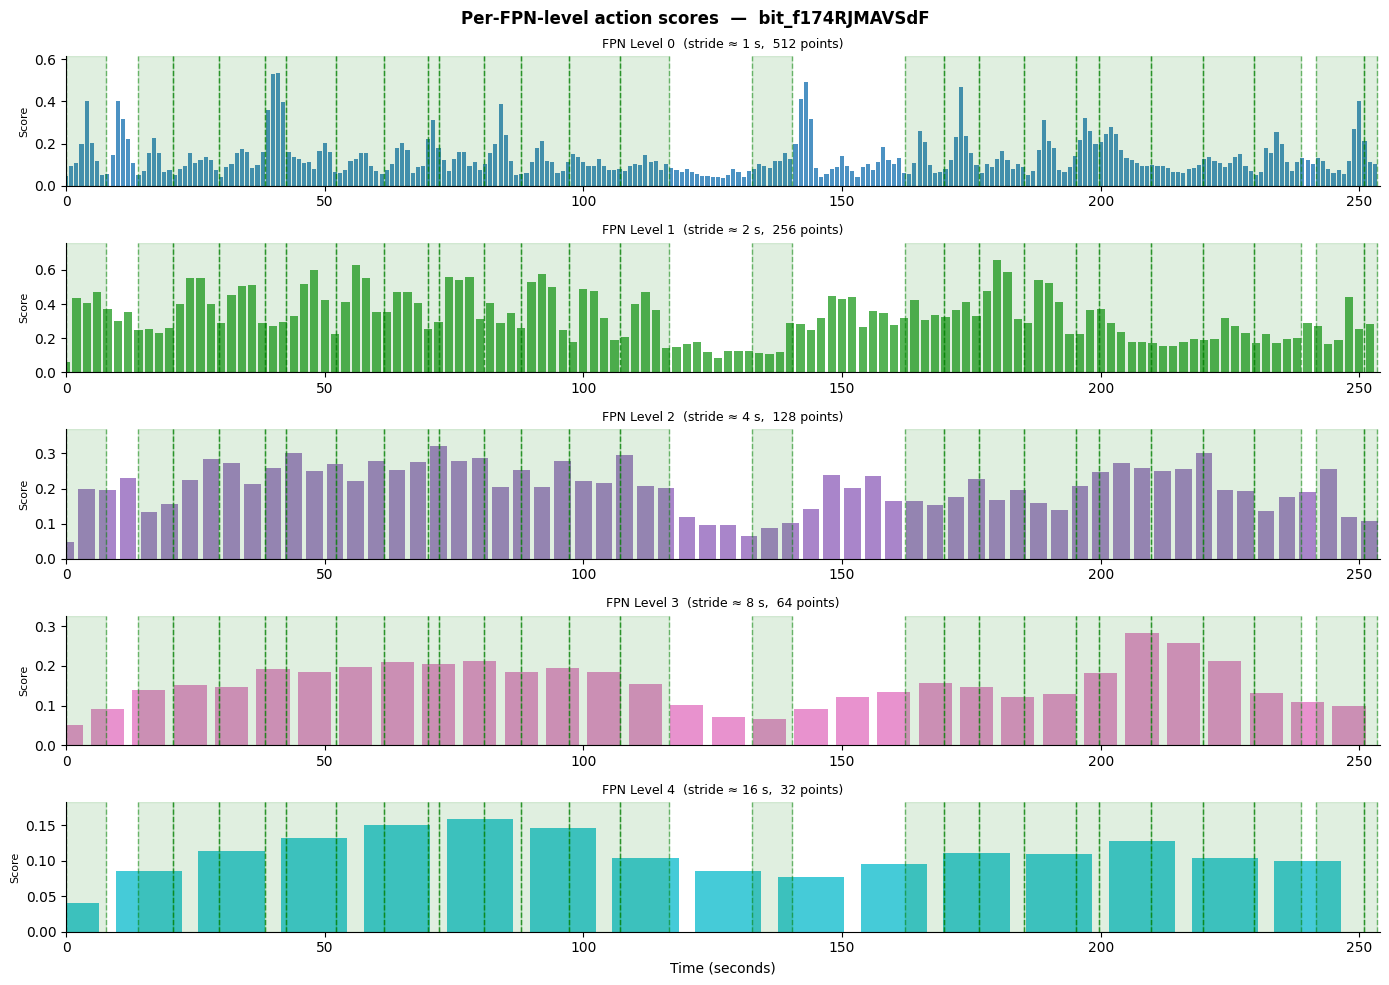

In [28]:
n_levels = len(level_scores)
fig, axes = plt.subplots(n_levels, 1, figsize=(14, 2 * n_levels), sharex=False)
if n_levels == 1:
    axes = [axes]

gt_segs = []
if VIDEO_ID in annotations:
    for ann in annotations[VIDEO_ID].get('annotations', []):
        gt_segs.append(ann['segment'])

colours = plt.cm.tab10(np.linspace(0, 0.9, n_levels))

for lvl, (ax, scores, times) in enumerate(zip(axes, level_scores, level_times)):
    stride = int(round(times[1] - times[0])) if len(times) > 1 else 1
    ax.bar(times, scores, width=stride * 0.8, color=colours[lvl], alpha=0.8)
    for s, e in gt_segs:
        ax.axvspan(s, e, alpha=0.12, color='green')
        ax.axvline(s, color='green', linewidth=1.0, linestyle='--', alpha=0.5)
        ax.axvline(e, color='green', linewidth=1.0, linestyle='--', alpha=0.5)
    ax.set_xlim(0, duration)
    ax.set_ylim(0, max(scores.max() * 1.15, 0.05))
    ax.set_ylabel('Score', fontsize=8)
    ax.set_title(f'FPN Level {lvl}  (stride ≈ {stride} s,  {len(times)} points)', fontsize=9)

axes[-1].set_xlabel('Time (seconds)', fontsize=10)
fig.suptitle(f'Per-FPN-level action scores  —  {VIDEO_ID}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()